In [1]:
import json
import requests
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Configuration de l'URL
url = "http://chendeb.free.fr/infoclimat.json"
print("R\u00e9cup\u00e9ration des donn\u00e9es depuis l'API Infoclimat...")

try:
    api_request = requests.get(url)
    data = json.loads(api_request.content)
except Exception as e:
    print(f"Erreur lors de la requ\u00eate : {e}")

Récupération des données depuis l'API Infoclimat...


Traitement classique des données...


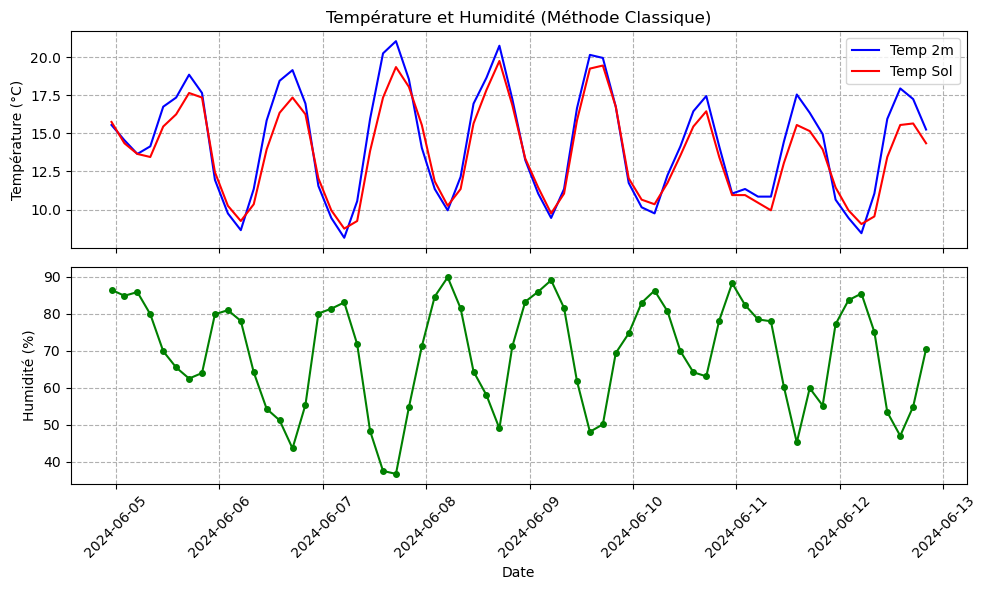

In [3]:
# --- PARTIE 1 : M\u00e9thode Classique (Listes et Boucles) ---
print("Traitement classique des donn\u00e9es...")

# Nettoyage des cl\u00e9s inutiles
keys_to_remove = ['request_state', 'request_key', 'message', 'model_run', 'source']
for key in keys_to_remove:
    data.pop(key, None)

# Extraction et conversion
lesDates = [datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S") for date_str in data.keys()]
lesTempA2m = [data[date_str]['temperature']['2m'] - 273.15 for date_str in data.keys()]
lesTempAuSol = [data[date_str]['temperature']['sol'] - 273.15 for date_str in data.keys()]
lesHumiditesA2m = [data[date_str]['humidite']['2m'] for date_str in data.keys()]

# Affichage du premier graphique
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

ax1.plot(lesDates, lesTempA2m, color='blue', label='Temp 2m')
ax1.plot(lesDates, lesTempAuSol, color='red', label='Temp Sol')
ax1.set_ylabel('Temp\u00e9rature (\u00b0C)')
ax1.set_title('Temp\u00e9rature et Humidit\u00e9 (M\u00e9thode Classique)')
ax1.grid(True, linestyle='--')
ax1.legend()

ax2.plot(lesDates, lesHumiditesA2m, color='green', marker='o', markersize=4)
ax2.set_ylabel('Humidit\u00e9 (%)')
ax2.set_xlabel('Date')
ax2.grid(True, linestyle='--')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# --- PARTIE 2 : M\u00e9thode Optionnelle (Pandas) ---
print("Traitement des donn\u00e9es avec Pandas...")

try:
    # 1. Lecture du JSON avec Pandas
    dfjson = pd.read_json(api_request.content, orient='index')

    # 2. Nettoyage des donn\u00e9es
    dfjson = dfjson.drop(keys_to_remove, axis=0, errors='ignore')

    # 3. Conversion de l'index en format datetime
    dfjson.index = pd.to_datetime(dfjson.index)

    # 4. Splitter les informations (json_normalize sur la colonne temp\u00e9rature)
    dfsplited = pd.json_normalize(dfjson['temperature'])

    # 5. Ajouter time as index
    dfsplited.index = dfjson.index

    # Conversion des temp\u00e9ratures en Celsius pour le graphique
    dfsplited['2m'] = dfsplited['2m'] - 273.15
    dfsplited['sol'] = dfsplited['sol'] - 273.15

    # Extraction de l'humidit\u00e9 pour le graphique
    df_humidite = pd.json_normalize(dfjson['humidite'])
    df_humidite.index = dfjson.index

    # 6. Plot avec pandas
    fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Tracer les temp\u00e9ratures
    dfsplited[['2m', 'sol']].plot(ax=ax3, color=['blue', 'red'], grid=True)
    ax3.set_ylabel('Temp\u00e9rature (\u00b0C)')
    ax3.set_title('Temp\u00e9rature et Humidit\u00e9 (M\u00e9thode Pandas)')
    ax3.legend(['Temp 2m', 'Temp Sol'])

    # Tracer l'humidit\u00e9
    df_humidite['2m'].plot(ax=ax4, color='green', marker='o', markersize=4, grid=True)
    ax4.set_ylabel('Humidit\u00e9 (%)')
    ax4.set_xlabel('Date')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Erreur lors de l'ex\u00e9cution avec Pandas : {e}")

Traitement des données avec Pandas...
Erreur lors de l'exécution avec Pandas : Expected file path name or file-like object, got <class 'bytes'> type
